# Practical 3:   Discrete Dislocation Dynamics simulation

**Course:** Materials Simulation Practical  
**Supervisor:** Paolo Moretti    
**Chair:** Chair of Materials Simulation (WW8)  
**Student:** Huseyn Shahhuseynov

<br><br>



## Task 1.

<br><br>

As required by the task, a single dislocation segment of length **100 nanometers (nm)** is defined in the `SegCu` input file of **microMegas (mM)**. The physical segment length is converted into simulation units using the **Lattice Simulation Parameter (LSM)** and the chosen **Basis Vector for Dislocations (BVD)** direction. According to the information in the `SegCu` file, the LSM is:

<br>

$$
\text{LSM} \approx 1.2183 \times 10^{−9} \space \text{meters} = 1.2183 \space \text{nm}
$$

<br>


For this simulation, the dislocation is modeled in a face-centered cubic (FCC) crystal structure with glide on the $(\bar{1} \ \bar{1} \ \bar{1})$ slip plane and Burgers vector $[1 \ 0 \ \bar{1}]$. To construct the dislocation line along this slip system, **BVD index 3** is selected from the `BVD.CFC` file (located in `dd/out/BVD`). This index corresponds to a slip direction vector—referred to as “ligne” in the BVD file—given as $[2, -4, 2]$.

<br><br>

To define a total dislocation length of 100 nm, the segment length is entered in `SegCu` (column~5) which is defined in BVD units. One BVD unit corresponds to a physical length equal to the product of the scale factor Echelle and the Burgers magnitude $|\mathbf{b}|$ provided in `in/Cu`. Using $\text{Echelle} = 13.5$ and $|\mathbf{b}| = \text{VecBurgers} = 2.5525 \space \text{Å} = 0.25525 \space \text{nm}$, is is obtained:

<br><br>

$$
1~\text{BVD} \;=\; 13.5 \times 0.25525~\text{nm}
\;=\; 3.445875~\text{nm}.
$$

<br><br>

Consequently, a target physical length of $L=100 \space \text{nm}$ corresponds to:

<br><br>

$$
N_{\text{BVD}} = \frac{L}{1 \space \text{BVD}} = \frac{100 \space \text{nm}}{3.445875 \space \text{nm}} \approx 29.02 \Rightarrow \boxed{N_{\text{BVD}}=29}.
$$

<br><br>

This integer value, **29**, is inserted into **column 5** of the dislocation segment definition in the `SegCu` file. This ensures that the simulated segment has a total pin-to-pin length of approximately 100 nm.

<br><br>

The simulation box size is set to **3 micrometers (µm)** in all directions. Using the LSM value, the box length in simulation units is computed as:

$$
\text{round} \left(\frac {3 \space \text {µm}} {1.2183 \space \text{nm}} \right) = 2464 \space \text{LSM}
$$

The dislocation segment is positioned at the center of the box: $(1232, 1232, 1232)$.

<br><br>

For completeness, the `SegCu` file structure is organized as follows:

- **Line 1**: Slip-system Schmid-factor switches (1 = use physical Schmid factor, 0 = artificially set to zero).
- **Line 2**: Number of segments (here: 1).
- **Line 3**: Simulation box dimensions in LSM units (2464, 2464, 2464).
- **Line 4**: Segment definition with columns:  
  (1) index,  
  (2–4) origin $x, y, z$ (LSM),  
  (5) segment length in BVD units $n_k$,  
  (6) BVD index $k$,  
  (7–10) neighbor indices (0 = pinned, negative = to be checked/kneecap),  
  (11) junction flag,  
  (12) junction partner index,  
  (13) cross-slip flag.

The actual input used is:

---

1 1 1 1 1 1 1 1 1 1 1 1  
1  
2464 2464 2464  
1 1232 1232 1232 29 3 0 0 0 0 F 0 0


---

which defines a single pinned edge dislocation segment of 100 nm aligned along BVD index 3.

<br><br>

To run the simulation, the **deformation mode** is set to **constant stress** (mode 4 in `ContCu`). The following parameters are defined there:
- Slip plane: $(\bar{1} \ \bar{1} \ \bar{1})$
- Burgers vector: $[1 \ 0 \ \bar{1}]$
- Number of time steps: 100,000
- Applied initial stress values $\sigma_0$, over which the simulation is run in increments.


In constant-stress loading mode (deformation mode 4 in `ContCu`), a tensile stress $\sigma_0$ is prescribed and the corresponding resolved shear stress $\tau$ on the active slip system is computed using the Schmid factor $m$:

<br><br>

$$
\tau = m \cdot \sigma_0
$$

<br><br>

The Schmid factor depends on the crystallographic orientation and, for FCC, it is calculated as:

<br><br>

$$
m = \cos(\phi) \cos(\lambda)
$$

<br><br>

Where $\phi$ is the angle between the loading direction and the slip plane normal, and $\lambda$ is the angle between the loading direction and the Burgers vector. Under the assumption of uniaxial loading along the crystallographic direction $[001]$, and with the selected slip system defined by the slip plane $(\bar{1}\ \bar{1}\ \bar{1})$ and the Burgers vector $[1\ 0\ \bar{1}]$, the Schmid factor can be determined as follows:


$$
\cos(\phi) = \frac{ \left| [001] \cdot \left[\bar{1}\ \bar{1}\ \bar{1} \right] \right| }{ \left\| [001] \right\| \cdot \left\| \left[ \bar{1}\ \bar{1}\ \bar{1} \right] \right\| } = \frac {1} {\sqrt{3}}
$$

$$
\cos(\lambda) = \frac{ \left| [001] \cdot \left[ 1 \ 0 \ \bar{1} \right] \right| }{ \left\| [001] \right\| \cdot \left\| \left[ 1 \ 0 \ \bar{1} \right] \right\| } = \frac {1} {\sqrt{2}}
$$

<br><br>

$$
m = \cos(\phi) \cos(\lambda) = \frac {1} {\sqrt{3}} \cdot \frac {1} {\sqrt{2}} =  \frac {1} {\sqrt{6}} \approx 0.408
$$

<br><br>

The Schmid factor $m$ quantifies the projection of the applied stress onto the resolved shear stress acting on the slip system. With the geometric orientation of the system and loading direction now specified, an estimate for the critical resolved shear stress $\tau_{\text{crit}}$ required for dislocation activation can be obtained using the Frank–Read relation:

<br><br>

$$
\tau_{\text{crit}} = 2 \alpha \frac {\mu b} {L}
$$

<br><br>

In this relation, $\mu$ is the shear modulus, $b$ is the magnitude of the Burgers vector, $L$ is the dislocation segment length, and $\alpha$ is a geometrical factor depending on the initial line segment orientation and the material properties with $\alpha = 0.5$ for an initially edge segment (and $\alpha = 1.5$ for screw). For copper, the material parameters are taken from `dd/in/Cu`as:

$ \mu = 42\ \text{GPa} = 42 \times 10^9\ \text{Pa}, \quad b = 2.5525\ \text{Å} = 0.25525\ \text{nm}, \quad L = 100\ \text{nm}$

Substituting these values with $\alpha = 0.5$ (appropriate for an initially edge dislocation segment), the estimated critical shear stress is:

<br><br>

$$
\tau_{\text{crit}} = 2 \times 0.5 \cdot \frac{42 \times 10^9\ \text{Pa} \cdot 0.25525 \times 10^{-9}\ \text{m}}{100 \times 10^{-9}\ \text{m}} \approx 107.2 \ \text{MPa}
$$

<br><br>

This value represents the estimated threshold of shear stress that will initiate dislocation bow-out in the simulation. Accordingly, the range of $\sigma_0 ( = \tau_{\text{crit}})$ values explored during the simulation was swept extending from 100 MPa to 200 MPa to capture the activation behavior across the critical point.

To determine the corresponding externally applied tensile stress $\sigma_0$, the resolved shear stress is related to the applied stress via the Schmid factor:

<br><br>


$$
\sigma = \frac{\tau_{\text{crit}}}{m} = \frac{107.2}{0.408} \approx 262.8\ \text{MPa}
$$



τcrit ≈ 154.800 MPa
σcrit = τcrit/m ≈ 379.181 MPa
α ≈ 0.722


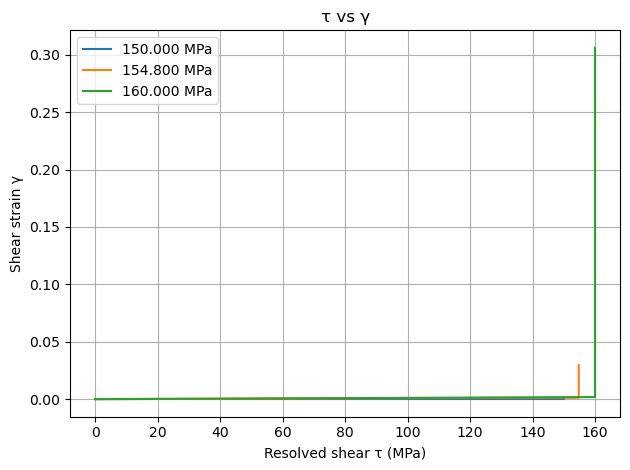

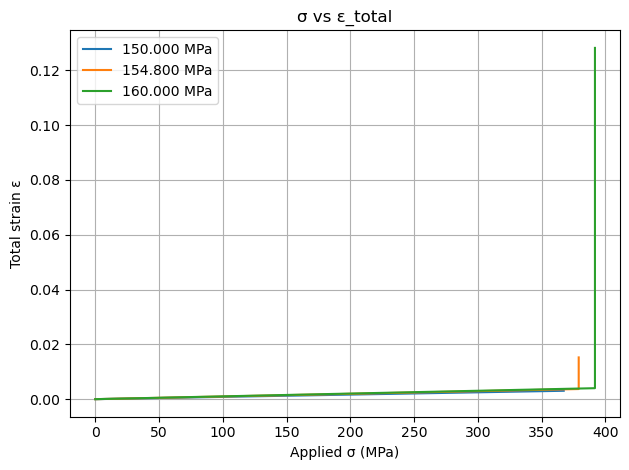

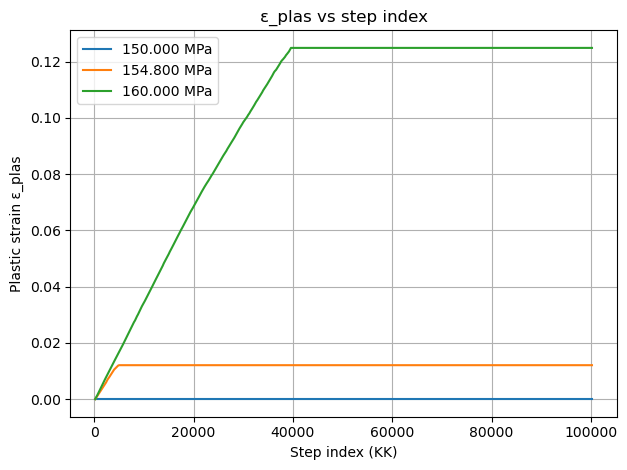

In [1]:
from pathlib import Path
import pandas as pd, numpy as np
import matplotlib.pyplot as plt

# Folder Paths
runs = [
    (r"C:\Users\Huseyn\OneDrive - Baku Higher Oil School\Desktop\Practical 3\mM\dd\results\S150MPa",   150.0),
    (r"C:\Users\Huseyn\OneDrive - Baku Higher Oil School\Desktop\Practical 3\mM\dd\results\S154.8MPa", 154.8),
    (r"C:\Users\Huseyn\OneDrive - Baku Higher Oil School\Desktop\Practical 3\mM\dd\results\S160MPa",   160.0),
]

def load_graph(gfile: Path) -> pd.DataFrame:
    # Reading Fortran-style exponents and converting 'D' -> 'E', then to numeric
    g = pd.read_csv(
        gfile, delim_whitespace=True, header=None, comment="#",
        engine="python", dtype=str
    ).apply(lambda c: c.str.replace('D','E',regex=False))
    g = g.apply(pd.to_numeric, errors='coerce').dropna().reset_index(drop=True)

    # Mapping columns. EPS_TOT/EPS_PLA/GAMMA are in percent → convert to unitless (/100).
    df = pd.DataFrame({
        "KK":        g.iloc[:, 0],
        "eps_total": g.iloc[:, 1] / 100.0,
        "eps_plas":  g.iloc[:, 2] / 100.0,
        "sigma":     g.iloc[:, 3],
        "gamma":     g.iloc[:, 4] / 100.0,
        "tau":       g.iloc[:, 5],
    }).sort_values("KK").reset_index(drop=True)
    return df

# τ vs γ
plt.figure()
for folder, s0 in sorted(runs, key=lambda x: x[1]):
    df = load_graph(Path(folder)/"graph.txt")
    plt.plot(df["tau"], df["gamma"], label=f"{s0:.3f} MPa")
plt.xlabel("Resolved shear τ (MPa)")
plt.ylabel("Shear strain γ")
plt.title("τ vs γ")
plt.grid(True); plt.legend(); plt.tight_layout()

# σ vs ε_total
plt.figure()
for folder, s0 in sorted(runs, key=lambda x: x[1]):
    df = load_graph(Path(folder)/"graph.txt")
    plt.plot(df["sigma"], df["eps_total"], label=f"{s0:.3f} MPa")
plt.xlabel("Applied σ (MPa)")
plt.ylabel("Total strain ε")
plt.title("σ vs ε_total")
plt.grid(True); plt.legend(); plt.tight_layout()

# ε_plas vs step index (KK)
plt.figure()
for folder, s0 in sorted(runs, key=lambda x: x[1]):
    df = load_graph(Path(folder)/"graph.txt")
    plt.plot(df["KK"], df["eps_plas"], label=f"{s0:.3f} MPa")
plt.xlabel("Step index (KK)")
plt.ylabel("Plastic strain ε_plas")
plt.title("ε_plas vs step index")
plt.grid(True); plt.legend(); plt.tight_layout()

# Summary
mu = 42e9; b = 0.25525e-9; L = 100e-9
m = 1/np.sqrt(6)
tau_crit = 154.8
sigma_crit = tau_crit / m
alpha = (tau_crit*1e6) * L / (2 * mu * b)
print(f"τcrit ≈ {tau_crit:.3f} MPa")
print(f"σcrit = τcrit/m ≈ {sigma_crit:.3f} MPa")
print(f"α ≈ {alpha:.3f}")


The critical resolved shear stress, $\tau_{\text{crit}}$ was operationally defined as the smallest applied $\tau$ that produced bow-out of the pinned segment and a finite, macroscopically measurable plastic response (a non-zero shear strain $\gamma$ after the initial transient). From the $\tau - \gamma$ plot, essentially no shear strain was recorded at $\tau=150 \space \text{MPa}$ across the loading values (blue curve remains near zero). A sharp onset of shear strain was first observed at $\tau = 154.8 \space \text{MPa}$ (orange curve), while a much larger response was obtained at $\tau = 160 \space \text{MPa}$ (green curve). This threshold-like increase of $\gamma$ between 150 and 160 MPa is characteristic of source activation and was therefore used to bracket $\tau_{\text{crit}}$. The smallest $\tau$ that yielded a measurable $\gamma$ was 154.8 MPa, so $\fbox{$\tau_{\text{crit}} = 154.8  \space \text{MPa}$}$ was identified.

<br><br>

The applied tensile stress $\sigma$ relates to the resolved shear stress through the Schmid factor $ m = 1 / \sqrt{6} \approx 0.409$ (as derived above). The $\sigma - \epsilon$ plot starts to show a clear “knee” where the total strain starts to grow rapidly at $\sigma \approx 380  \space \text{MPa}$. By $\sigma = \tau / m$, the corresponding shear stress value is $\tau \approx 380 \times 0.408 \approx 155 \space \text{MPa}$, which is consistent with $\tau_{\text{crit}} = 154.8 \space \text{MPa}$.

The plastic-strain–versus–step (KK) plot further supports this result. At $\tau = 150  \space \text{MPa}$, the plastic strain remained essentially zero over $10^5$ steps, indicating that the segment did not operate as a source. At $\tau = 154.8 \space \text{MPa}$, a finite plastic strain appeared and then plateaued, evidencing that the source activated (loop emission occurred) and the plastic increment persisted. At $\tau = 160  \space \text{MPa}$, the plastic strain increased by an order of magnitude over many steps before saturating, which is consistent with repeated source operation at supercritical stress.

The 3-D configurations also show how the dislocation segment behaves during source activation:

Below critical (100 MPa): the segment remained nearly straight, showing only elastic bowing. No loop emission was observed.

<img src="Far_below.png" width="350">

Near but below critical (150 MPa): a stable semicircular bow shape formed but did not run away; the line tension balanced the Peach–Koehler force and no sustained growth occurred.

<img src="Below_critical.png" width="350">

At the identified threshold (154.8 MPa): the pinned segment bowed out past the semicircle, indicating that the Peach–Koehler force exceeded the restoring line tension; a loop was emitted and a finite plastic increment was recorded. The static snapshots show the post-activation bowed shape consistent with loop formation.

<img src="Critical.png" width="350">

Above critical (160 MPa): periodic bow-out and repeated loop emission were observed in the video, which is the hallmark of a supercritical Frank–Read source.

<video src="microMegas.mp4" width="500" controls></video>


These configuration changes are the expected sequence for a pinned segment as $\tau$ crosses the critical value: from elastic bowing (subcritical) → unstable bow-out with loop emission (critical) → repeated operation (supercritical). The first stress at which the unstable bow-out and loop emission appear is 

$$
\fbox { $ \tau_{\text{crit}} = 154.8 \space \text {MPa} $ }
$$

From this critical value, the effective line-tension factor $\alpha$ can be obtained from the Frank–Read relation:

$$
\fbox { $ \alpha = \frac {\tau_{\text{crit}} L} {2 \mu b} = \frac {154.8 \space \text {MPa} \space 100 \space \text{nm} } { 2 \space 42 \space \text{GPa} \space 0.25525 \space {nm} } = 0.722$ }
$$


It may be noted that these values exceed the simple Frank–Read estimates calculated above. The upward shift is plausibly explained by numerical and physical factors such as the discrete line representation, free-surface/image-like effects from periodic boundaries and finite box size, nonlocal line tension, and the precise initial orientation relative to the chosen BVD and slip system.

## Task 2

<br><br>

To ivestigate the dependence of the critical resolved shear stress $\tau_{\text{crit}}$ on dislocation segment length $L$, the simulations were performed for lengths between 50 nm and 200 nm with increments of 25 nm. The obtained values of $\tau_{\text{crit}}$ were compared to the analytical prediction from the Frank–Read relation:

$$
\tau_{\text{crit}} = \frac{2 \alpha \mu b}{L},
$$

using $\alpha = 0.5$, $\mu = 42$ GPa, and $b = 0.25525$ nm.

,Length (nm),τ_sim (MPa),τ_analytical (MPa),Rel. error (%),α_eff
0,50,233.3,214.4,8.8,0.54
1,75,120.2,142.9,15.9,0.42
2,100,154.8,107.2,44.4,0.72
3,125,60.2,85.8,29.8,0.35
4,150,50.1,71.5,29.9,0.35
5,175,40.5,61.3,33.9,0.33
6,200,40.1,53.6,25.2,0.37


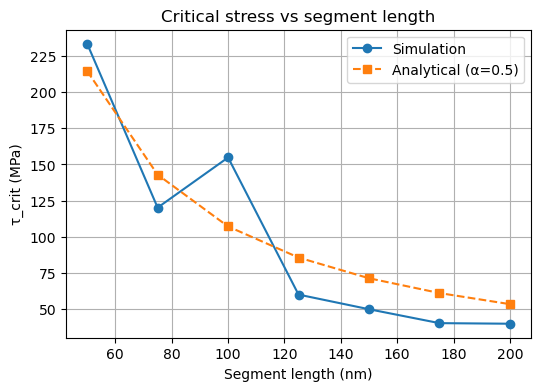

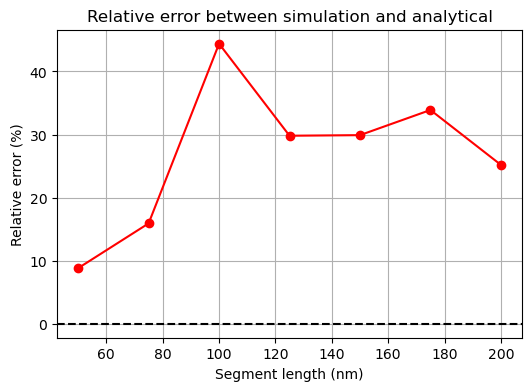

In [2]:
from IPython.display import display

# Material parameters
mu = 42e9              # Pa
b = 0.25525e-9         # m
alpha_assumed = 0.5    # for analytical reference

# Simulation Data
lengths_nm = np.array([50, 75, 100, 125, 150, 175, 200])  # nm
tau_sim = np.array([233.3, 120.2, 154.8, 60.2, 50.1, 40.5, 40.1]) * 1e6  # Pa

# Analytical tau_crit
lengths_m = lengths_nm * 1e-9
tau_analytical = 2 * alpha_assumed * mu * b / lengths_m  # Pa

# Relative error (%)
rel_error = np.abs( (tau_sim - tau_analytical) / tau_analytical * 100 )

# Alpha_simulations
alpha_eff = tau_sim * lengths_m / (2 * mu * b)

# Table
df = pd.DataFrame({
    "Length (nm)": lengths_nm,
    "τ_sim (MPa)": tau_sim/1e6,
    "τ_analytical (MPa)": tau_analytical/1e6,
    "Rel. error (%)": rel_error,
    "α_eff": alpha_eff
})

df["τ_analytical (MPa)"] = df["τ_analytical (MPa)"].round(1)
df["Rel. error (%)"] = df["Rel. error (%)"].round(1)
df["α_eff"] = df["α_eff"].round(2)

display(df)

# Simulation vs Analytical tau_crit Plot
plt.figure(figsize=(6,4))
plt.plot(lengths_nm, tau_sim/1e6, "o-", label="Simulation")
plt.plot(lengths_nm, tau_analytical/1e6, "s--", label=f"Analytical (α={alpha_assumed})")
plt.xlabel("Segment length (nm)")
plt.ylabel("τ_crit (MPa)")
plt.legend()
plt.grid(True)
plt.title("Critical stress vs segment length")
plt.show()

# Relative error Plot
plt.figure(figsize=(6,4))
plt.plot(lengths_nm, rel_error, "o-r")
plt.axhline(0, color="k", linestyle="--")
plt.xlabel("Segment length (nm)")
plt.ylabel("Relative error (%)")
plt.title("Relative error between simulation and analytical")
plt.grid(True)
plt.show()

The results indicate that both simulation and analytical values follow the expected inverse scaling with segment length. The best agreement is observed at the shortest lengths of 50 and 75 nm, where the relative error is below 20%. At 100 nm, the deviation becomes most pronounced, with the simulation giving a much higher stress than predicted, corresponding to a relative error of approximately 44%. For longer lengths (125–200 nm), the discrepancy remains significant but stabilizes within 25–35%.

To assess which length matches the analytical solution better, the relative error plot is examined. The smallest errors are clearly associated with the shortest segments, meaning that the Frank–Read formula provides the most accurate description in this regime. At larger lengths, the simulation consistently produces higher stresses, suggesting that the analytical model underestimates the stress required for source activation.

The factors responsible for these deviations can be associated with limitations of both the analytical model and the discrete simulation. The analytical Frank–Read expression is based on a simplified line-tension approximation with a constant $\alpha$, neglecting nonlocal effects and geometric details of the dislocation bow-out. In contrast, the simulation includes a discrete line representation, where the minimum segment length imposes constraints on curvature, effectively increasing the line tension. The finite box size and periodic boundary conditions introduce image stresses, which become more relevant for longer dislocation lengths. These influences modify the effective $\alpha$, which was extracted from the simulations to be higher than 0.5 for intermediate lengths (e.g. $\alpha = 0.72$ at 100 nm) and lower (0.33–0.37) at longer lengths.

A brief note on the anomaly at 100 nm: The overshoot observed at 100 nm disappears when the segment length is set to 28 BVD (≈ 96.5 nm), giving $\tau = 72.8 \space \text{MPa}$ and $\alpha = 0.34$ consistent with the neighboring points. This confirms that the anomaly originated from BVD/meshing commensurability effects rather than a physical trend, however I kept the 29 BVD case to highlight this anomaly.

The analysis shows how the agreement between simulation and analytical solution depends strongly on segment length, with short segments matching well and longer ones deviating due to physical and numerical effects inherent to the DDD framework.

## Task 3.

<br><br>

Starting from the Task 1 setup (slip plane $(\bar{1}\,\bar{1}\,\bar{1})$, $\mathbf{b}\parallel[1\,0\,\bar{1}]$, and segment length fixed at $29$ BVD $\approx 100$ nm), the intended procedure was to vary the character angle $\beta$ between the dislocation line and the Burgers vector while keeping the slip plane and $\mathbf{b}$ unchanged. 

In microMegas, the segment orientation chosen via `SegCu` column 6 is taken from `BVD.CFC`, where each index specifies both the line direction (“ligne”) and the Burgers vector direction (“Dep”). For the plane $(\bar{1}\,\bar{1}\,\bar{1})$ in the provided `BVD.CFC`, it was verified that all available entries satisfy  

$$
\text{ligne}\cdot\text{Dep}=0,
$$  

i.e. they initialize Pure Edge segments. No mixed or screw entries are defined for this plane.  

An eight-point $\beta$-sweep (targeting $\beta=0^\circ,15^\circ,30^\circ,45^\circ,60^\circ,75^\circ,90^\circ$) was therefore attempted by editing `BVD.CFC` to add (or replace) indices that preserve $\mathbf{b}\parallel[1\,0\,\bar{1}]$ and rotate only the in-plane line direction. However, with the current executable, `BVD.CFC` seems as a fixed lookup table which is tightly coupled to internal cross-slip mappings. Modifying the numeric block (either by appending rows and updating the header count, or by replacing rows in place) led to segmentation faults at start-up, indicating that the parser expects the original table values. As a result, the $\beta$-sweep could not be carried out within the current binary and input format.  
